<a href="https://colab.research.google.com/github/yogitaalone04-web/Market-Basket-Analysis-ML/blob/main/Market_Basket_Analysis_LR_DT_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML TAE

NAME: Shinam Sheikh     USN NO: CS24D010

**TOPIC:** Market Basket Analysis &nbsp;&nbsp; **DATASET:** Groceries Dataset

---

## Import Libraries

In [ ]:
!pip install mlxtend -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries imported successfully!')

All libraries imported successfully!


## Mount Google Drive & Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Yeh line use karo - header=None aur engine='python'
df_raw = pd.read_csv('/content/drive/MyDrive/ML_dataset/groceries.csv',
                      header=None,
                      engine='python',
                      on_bad_lines='skip')

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6106 entries, 0 to 6105
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       6106 non-null   object
 1   1       3947 non-null   object
 2   2       2304 non-null   object
 3   3       1005 non-null   object
dtypes: object(4)
memory usage: 190.9+ KB


In [ ]:
df_raw.describe()

,0,1,2,3
count,6106,3947,2304,1005
unique,158,149,141,112
top,whole milk,rolls/buns,soda,shopping bags
freq,525,307,166,112


## Build Transactions

In [ ]:
import csv


transactions = []
with open('/content/drive/MyDrive/ML_dataset/groceries.csv', 'r') as f:
    reader = csv.reader(f)
    for row in reader:
        clean = [item.strip() for item in row if item.strip() != '']
        if clean:
            transactions.append(clean)

item_series = pd.Series([item for t in transactions for item in t])

print('Total transactions :', len(transactions))
print('Unique items       :', item_series.nunique())
print('Sample             :', transactions[0])

Total transactions : 9835
Unique items       : 169
Sample             : ['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups']


In [ ]:
item_series.value_counts()

,count
whole milk,2513
other vegetables,1903
rolls/buns,1809
soda,1715
yogurt,1372
...,...
bags,4
kitchen utensil,4
preservation products,2
baby food,1


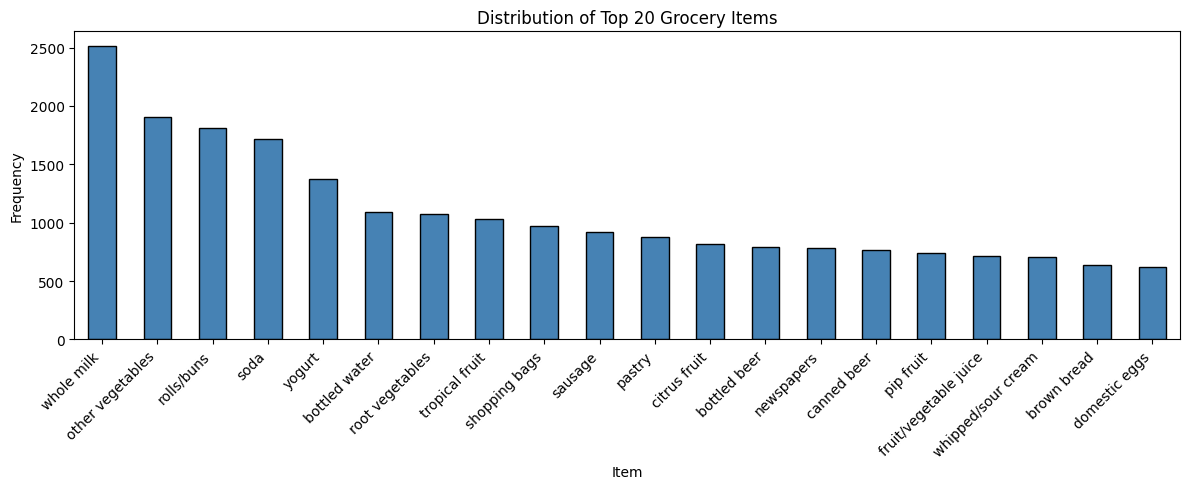

In [ ]:
# Top 20 Most Purchased Items
plt.figure(figsize=(12, 5))
item_series.value_counts().head(20).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Top 20 Grocery Items')
plt.xlabel('Item')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

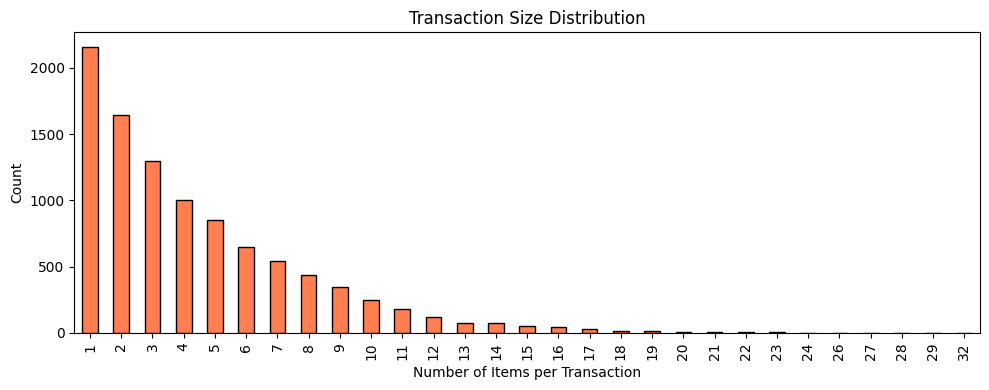

count    9835.000000
mean        4.409456
std         3.589385
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        32.000000
dtype: float64


In [ ]:
# Transaction size distribution
t_sizes = pd.Series([len(t) for t in transactions])
plt.figure(figsize=(10, 4))
t_sizes.value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Transaction Size Distribution')
plt.xlabel('Number of Items per Transaction')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(t_sizes.describe())

## Apriori — Association Rules

In [ ]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)
print('Basket encoded shape:', basket_df.shape)
basket_df.head()

Basket encoded shape: (9835, 169)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
frequent_items = apriori(basket_df, min_support=0.01, use_colnames=True)
frequent_items.sort_values('support', ascending=False, inplace=True)
print('Frequent itemsets found:', len(frequent_items))
frequent_items.head(10)

Frequent itemsets found: 333


,support,itemsets
86,0.255516,(whole milk)
55,0.193493,(other vegetables)
66,0.183935,(rolls/buns)
75,0.174377,(soda)
87,0.139502,(yogurt)
6,0.110524,(bottled water)
67,0.108998,(root vegetables)
81,0.104931,(tropical fruit)
73,0.098526,(shopping bags)
70,0.093950,(sausage)


In [ ]:
rules = association_rules(frequent_items, metric='lift', min_threshold=1.0)
rules.sort_values('lift', ascending=False, inplace=True)
print('Association rules generated:', len(rules))
rules[['antecedents','consequents','support','confidence','lift']].head(10)

Association rules generated: 598


,antecedents,consequents,support,confidence,lift
582,"(yogurt, whole milk)",(curd),0.010066,0.179673,3.372304
587,(curd),"(yogurt, whole milk)",0.010066,0.188931,3.372304
533,(root vegetables),"(other vegetables, citrus fruit)",0.010371,0.095149,3.295045
532,"(other vegetables, citrus fruit)",(root vegetables),0.010371,0.359155,3.295045
558,"(yogurt, other vegetables)",(whipped/sour cream),0.010168,0.234192,3.267062
563,(whipped/sour cream),"(yogurt, other vegetables)",0.010168,0.141844,3.267062
368,"(other vegetables, tropical fruit)",(root vegetables),0.012303,0.342776,3.144780
369,(root vegetables),"(other vegetables, tropical fruit)",0.012303,0.112873,3.144780
173,(beef),(root vegetables),0.017387,0.331395,3.040367
172,(root vegetables),(beef),0.017387,0.159515,3.040367


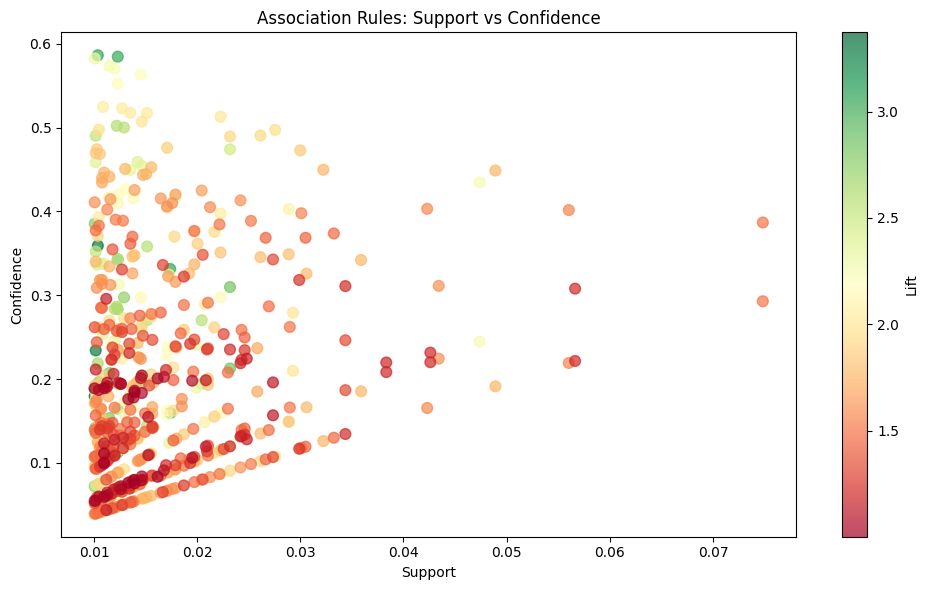

In [ ]:
# Support vs Confidence scatter
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rules['support'], rules['confidence'],
                      c=rules['lift'], cmap='RdYlGn', alpha=0.7, s=60)
plt.colorbar(scatter, label='Lift')
plt.title('Association Rules: Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.tight_layout()
plt.show()

## Feature Preparation for Classification

In [ ]:
# Keep transactions with >= 2 items
filtered = [t for t in transactions if len(t) >= 2]
print('Usable transactions (>=2 items):', len(filtered))

X_raw, y_raw = [], []
for t in filtered:
    X_raw.append(t[:-1])   # basket items as features
    y_raw.append(t[-1])    # last item as label

te2 = TransactionEncoder()
X_encoded = te2.fit_transform(X_raw)
X = pd.DataFrame(X_encoded.astype(int), columns=te2.columns_)

le = LabelEncoder()
y = le.fit_transform(y_raw)

print('Feature matrix shape:', X.shape)
print('Classes:', le.classes_)

Usable transactions (>=2 items): 7676
Feature matrix shape: (7676, 167)
Classes: ['Instant food products' 'UHT-milk' 'abrasive cleaner' 'artif. sweetener'
 'baby cosmetics' 'bags' 'baking powder' 'bathroom cleaner' 'beef'
 'berries' 'beverages' 'bottled beer' 'bottled water' 'brandy'
 'brown bread' 'butter' 'butter milk' 'cake bar' 'candles' 'candy'
 'canned beer' 'canned fish' 'canned fruit' 'canned vegetables' 'cat food'
 'cereals' 'chewing gum' 'chocolate' 'chocolate marshmallow'
 'citrus fruit' 'cleaner' 'cling film/bags' 'cocoa drinks' 'coffee'
 'condensed milk' 'cooking chocolate' 'cookware' 'cream' 'cream cheese'
 'curd' 'curd cheese' 'decalcifier' 'dental care' 'dessert' 'detergent'
 'dish cleaner' 'dishes' 'dog food' 'domestic eggs'
 'female sanitary products' 'flour' 'flower (seeds)'
 'flower soil/fertilizer' 'frozen dessert' 'frozen fish' 'frozen fruits'
 'frozen meals' 'frozen potato products' 'frozen vegetables'
 'fruit/vegetable juice' 'grapes' 'hair spray' 'hamburger mea

In [ ]:
print(X.shape)

(7676, 167)


In [ ]:
print(y.shape)

(7676,)


---
# Model 1 — Logistic Regression

### 70:30 Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape)

(5373, 167) (2303, 167)


In [ ]:
print(X_train)

      Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
6322                      0         0                 0                 0   
6340                      0         0                 0                 0   
4076                      0         0                 0                 0   
5357                      0         0                 0                 0   
4446                      0         0                 0                 0   
...                     ...       ...               ...               ...   
5226                      0         0                 0                 0   
5390                      0         0                 0                 0   
860                       0         0                 0                 0   
7603                      0         0                 0                 0   
7270                      0         0                 0                 0   

      baby cosmetics  baby food  baking powder  bathroom cleaner  beef  \
6

In [ ]:
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = lr_classifier.predict(X_test)
print(y_pred)

[123 113  11 ... 128 128 152]


In [ ]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 4 0 0]
 [0 0 0 ... 1 2 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print('Accuracy Score:')
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.15544941380807642


In [ ]:
print('Classification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           6       0.33      0.10      0.15        10
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         6
          11       0.15      0.11      0.13        82
          12       0.05      0.04      0.04        48
          13       0.00      0.00      0.00         3
          14       0.00      0.00      0.00        22
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         4
          17       0.00      0.00      0.00        15
          18       0.00      0.00      0.00        20
    

In [ ]:
# GridSearchCV — Logistic Regression (70:30)
lr = LogisticRegression(max_iter=1000, random_state=42)
Params = {
    'C'       : [0.1, 1, 10],
    'penalty' : ['l1', 'l2'],
    'solver'  : ['liblinear']
}
grid_search_lr = GridSearchCV(estimator=lr, param_grid=Params, cv=4, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)

Fitting 4 folds for each of 6 candidates, totalling 24 fits


GridSearchCV(cv=4, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy', verbose=1)

In [ ]:
print(grid_search_lr.best_score_)

0.1487049527089317


In [ ]:
print(grid_search_lr.best_params_)

{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


### 80:20 Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(6140, 167) (1536, 167)


In [ ]:
print(X_train)

      Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
501                       0         0                 0                 0   
5665                      0         0                 0                 0   
2855                      0         0                 0                 0   
2458                      0         0                 0                 0   
1539                      0         0                 0                 0   
...                     ...       ...               ...               ...   
5226                      0         0                 0                 0   
5390                      0         0                 0                 0   
860                       0         0                 0                 0   
7603                      0         0                 0                 0   
7270                      0         0                 0                 0   

      baby cosmetics  baby food  baking powder  bathroom cleaner  beef  \
5

In [ ]:
lr_classifier2 = LogisticRegression(max_iter=1000, random_state=42)
lr_classifier2.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred = lr_classifier2.predict(X_test)
print(y_pred)

[123 113  11 ...  59 123 123]


In [ ]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 3 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print('Accuracy Score:')
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.15755208333333334


In [ ]:
print('Classification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         7
           7       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         2
          11       0.26      0.19      0.22        57
          12       0.08      0.06      0.07        33
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00        16
          16       0.00      0.00      0.00         2
          17       0.00      0.00      0.00        12
          18       0.00      0.00      0.00        15
          19       0.12      0.03      0.04        39
          20       0.19      0.08      0.11        39
          21       0.00      0.00      0.00         3
    

In [ ]:
# GridSearchCV — Logistic Regression (80:20)
grid_search_lr2 = GridSearchCV(estimator=LogisticRegression(max_iter=1000, random_state=42), param_grid=Params, cv=4, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search_lr2.fit(X_train, y_train)

Fitting 4 folds for each of 6 candidates, totalling 24 fits


GridSearchCV(cv=4, estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy', verbose=1)

In [ ]:
print(grid_search_lr2.best_score_)

0.1535830618892508


In [ ]:
print(grid_search_lr2.best_params_)

{'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


In [ ]:
# Table 1 : 70:30 Split — Logistic Regression
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=42)
m = LogisticRegression(max_iter=1000, random_state=42)
m.fit(Xtr, ytr)
yp = m.predict(Xte)
rep = classification_report(yte, yp, output_dict=True, zero_division=0)
lr_t70 = pd.DataFrame([{
    'Split'         : '70:30',
    'Train Samples' : Xtr.shape[0],
    'Test Samples'  : Xte.shape[0],
    'Accuracy(%)'   : round(accuracy_score(yte, yp)*100, 2),
    'Precision(W)'  : round(rep['weighted avg']['precision']*100, 2),
    'Recall(W)'     : round(rep['weighted avg']['recall']*100, 2),
    'F1-Score(W)'   : round(rep['weighted avg']['f1-score']*100, 2)
}])
lr_t70.index += 1
print('===== Logistic Regression — Results Table : 70:30 Split =====')
lr_t70

===== Logistic Regression — Results Table : 70:30 Split =====


,Split,Train Samples,Test Samples,Accuracy(%),Precision(W),Recall(W),F1-Score(W)
1,70:30,5373,2303,15.54,9.78,15.54,10.7


In [ ]:
# Table 2 : 80:20 Split — Logistic Regression
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
m = LogisticRegression(max_iter=1000, random_state=42)
m.fit(Xtr, ytr)
yp = m.predict(Xte)
rep = classification_report(yte, yp, output_dict=True, zero_division=0)
lr_t80 = pd.DataFrame([{
    'Split'         : '80:20',
    'Train Samples' : Xtr.shape[0],
    'Test Samples'  : Xte.shape[0],
    'Accuracy(%)'   : round(accuracy_score(yte, yp)*100, 2),
    'Precision(W)'  : round(rep['weighted avg']['precision']*100, 2),
    'Recall(W)'     : round(rep['weighted avg']['recall']*100, 2),
    'F1-Score(W)'   : round(rep['weighted avg']['f1-score']*100, 2)
}])
lr_t80.index += 1
print('===== Logistic Regression — Results Table : 80:20 Split =====')
lr_t80

===== Logistic Regression — Results Table : 80:20 Split =====


,Split,Train Samples,Test Samples,Accuracy(%),Precision(W),Recall(W),F1-Score(W)
1,80:20,6140,1536,15.76,10.2,15.76,10.58


---
# Model 2 — Decision Tree

In [ ]:
print(X.shape)

(7676, 167)


In [ ]:
print(y.shape)

(7676,)


### 70:30 Split — Decision Tree

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape)

(5373, 167) (2303, 167)


In [ ]:
print(X_train)

      Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
6322                      0         0                 0                 0   
6340                      0         0                 0                 0   
4076                      0         0                 0                 0   
5357                      0         0                 0                 0   
4446                      0         0                 0                 0   
...                     ...       ...               ...               ...   
5226                      0         0                 0                 0   
5390                      0         0                 0                 0   
860                       0         0                 0                 0   
7603                      0         0                 0                 0   
7270                      0         0                 0                 0   

      baby cosmetics  baby food  baking powder  bathroom cleaner  beef  \
6

In [ ]:
dt_classifier = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

In [ ]:
y_pred = dt_classifier.predict(X_test)
print(y_pred)

[128 128  88 ... 128 128 123]


In [ ]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print('Accuracy Score:')
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.11767260095527572


In [ ]:
print('Classification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         6
          11       0.00      0.00      0.00        82
          12       0.00      0.00      0.00        48
          13       0.00      0.00      0.00         3
          14       0.00      0.00      0.00        22
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         4
          17       0.00      0.00      0.00        15
          18       0.00      0.00      0.00        20
    

In [ ]:
# GridSearchCV — Decision Tree (70:30)
dt = DecisionTreeClassifier(random_state=42)
Params = {
    'max_depth'        : [3, 5, 10, 15],
    'min_samples_leaf' : [1, 5, 10],
    'criterion'        : ['gini', 'entropy']
}
grid_search_dt = GridSearchCV(estimator=dt, param_grid=Params, cv=4, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

Fitting 4 folds for each of 24 candidates, totalling 96 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15],
                         'min_samples_leaf': [1, 5, 10]},
             scoring='accuracy', verbose=1)

In [ ]:
print(grid_search_dt.best_score_)

0.12395345796546467


In [ ]:
print(grid_search_dt.best_params_)

{'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1}


### 80:20 Split — Decision Tree

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(6140, 167) (1536, 167)


In [ ]:
print(X_train)

      Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
501                       0         0                 0                 0   
5665                      0         0                 0                 0   
2855                      0         0                 0                 0   
2458                      0         0                 0                 0   
1539                      0         0                 0                 0   
...                     ...       ...               ...               ...   
5226                      0         0                 0                 0   
5390                      0         0                 0                 0   
860                       0         0                 0                 0   
7603                      0         0                 0                 0   
7270                      0         0                 0                 0   

      baby cosmetics  baby food  baking powder  bathroom cleaner  beef  \
5

In [ ]:
dt_classifier2 = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
dt_classifier2.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)

In [ ]:
y_pred = dt_classifier2.predict(X_test)
print(y_pred)

[123 123 128 ... 123 123 123]


In [ ]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print('Accuracy Score:')
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.13151041666666666


In [ ]:
print('Classification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         7
           7       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00        57
          12       0.00      0.00      0.00        33
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00        16
          16       0.00      0.00      0.00         2
          17       0.00      0.00      0.00        12
          18       0.00      0.00      0.00        15
          19       0.00      0.00      0.00        39
          20       0.00      0.00      0.00        39
          21       0.00      0.00      0.00         3
    

In [ ]:
# GridSearchCV — Decision Tree (80:20)
grid_search_dt2 = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=Params, cv=4, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search_dt2.fit(X_train, y_train)

Fitting 4 folds for each of 24 candidates, totalling 96 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 15],
                         'min_samples_leaf': [1, 5, 10]},
             scoring='accuracy', verbose=1)

In [ ]:
print(grid_search_dt2.best_score_)

0.13273615635179153


In [ ]:
print(grid_search_dt2.best_params_)

{'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 10}


In [ ]:
# Table 1 : 70:30 Split — Decision Tree
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=42)
m = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
m.fit(Xtr, ytr)
yp = m.predict(Xte)
rep = classification_report(yte, yp, output_dict=True, zero_division=0)
dt_t70 = pd.DataFrame([{
    'Split'         : '70:30',
    'Train Samples' : Xtr.shape[0],
    'Test Samples'  : Xte.shape[0],
    'Accuracy(%)'   : round(accuracy_score(yte, yp)*100, 2),
    'Precision(W)'  : round(rep['weighted avg']['precision']*100, 2),
    'Recall(W)'     : round(rep['weighted avg']['recall']*100, 2),
    'F1-Score(W)'   : round(rep['weighted avg']['f1-score']*100, 2)
}])
dt_t70.index += 1
print('===== Decision Tree — Results Table : 70:30 Split =====')
dt_t70

===== Decision Tree — Results Table : 70:30 Split =====


,Split,Train Samples,Test Samples,Accuracy(%),Precision(W),Recall(W),F1-Score(W)
1,70:30,5373,2303,11.77,5.47,11.77,6.33


In [ ]:
# Table 2 : 80:20 Split — Decision Tree
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
m = DecisionTreeClassifier(max_leaf_nodes=10, random_state=0)
m.fit(Xtr, ytr)
yp = m.predict(Xte)
rep = classification_report(yte, yp, output_dict=True, zero_division=0)
dt_t80 = pd.DataFrame([{
    'Split'         : '80:20',
    'Train Samples' : Xtr.shape[0],
    'Test Samples'  : Xte.shape[0],
    'Accuracy(%)'   : round(accuracy_score(yte, yp)*100, 2),
    'Precision(W)'  : round(rep['weighted avg']['precision']*100, 2),
    'Recall(W)'     : round(rep['weighted avg']['recall']*100, 2),
    'F1-Score(W)'   : round(rep['weighted avg']['f1-score']*100, 2)
}])
dt_t80.index += 1
print('===== Decision Tree — Results Table : 80:20 Split =====')
dt_t80

===== Decision Tree — Results Table : 80:20 Split =====


,Split,Train Samples,Test Samples,Accuracy(%),Precision(W),Recall(W),F1-Score(W)
1,80:20,6140,1536,13.15,3.12,13.15,4.43


---
# Model 3 — Random Forest

In [ ]:
print(X.shape)

(7676, 167)


In [ ]:
print(y.shape)

(7676,)


### 70:30 Split — Random Forest

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape)

(5373, 167) (2303, 167)


In [ ]:
print(X_train)

      Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
6322                      0         0                 0                 0   
6340                      0         0                 0                 0   
4076                      0         0                 0                 0   
5357                      0         0                 0                 0   
4446                      0         0                 0                 0   
...                     ...       ...               ...               ...   
5226                      0         0                 0                 0   
5390                      0         0                 0                 0   
860                       0         0                 0                 0   
7603                      0         0                 0                 0   
7270                      0         0                 0                 0   

      baby cosmetics  baby food  baking powder  bathroom cleaner  beef  \
6

In [ ]:
rf_classifier = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=5, oob_score=True, random_state=42)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [ ]:
y_pred = rf_classifier.predict(X_test)
print(y_pred)

[123 123 123 ... 123 123 123]


In [ ]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print('Accuracy Score:')
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.12809379070777246


In [ ]:
rf_classifier.oob_score_

0.11669458403126745

In [ ]:
print('Classification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         1
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00         8
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         6
          11       0.00      0.00      0.00        82
          12       0.00      0.00      0.00        48
          13       0.00      0.00      0.00         3
          14       0.00      0.00      0.00        22
          15       0.00      0.00      0.00         1
          16       0.00      0.00      0.00         4
          17       0.00      0.00      0.00        15
          18       0.00      0.00      0.00        20
    

In [ ]:
# GridSearchCV — Random Forest (70:30)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
Params = {
    'max_depth'        : [2, 3, 5],
    'min_samples_leaf' : [5, 10, 20],
    'n_estimators'     : [10, 25, 30, 50]
}
grid_search_rf = GridSearchCV(estimator=rf, param_grid=Params, cv=4, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)

Fitting 4 folds for each of 36 candidates, totalling 144 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5],
                         'min_samples_leaf': [5, 10, 20],
                         'n_estimators': [10, 25, 30, 50]},
             scoring='accuracy', verbose=1)

In [ ]:
print(grid_search_rf.best_score_)

0.11967282957486793


In [ ]:
print(grid_search_rf.best_params_)

{'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 10}


### 80:20 Split — Random Forest

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(6140, 167) (1536, 167)


In [ ]:
print(X_train)

      Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
501                       0         0                 0                 0   
5665                      0         0                 0                 0   
2855                      0         0                 0                 0   
2458                      0         0                 0                 0   
1539                      0         0                 0                 0   
...                     ...       ...               ...               ...   
5226                      0         0                 0                 0   
5390                      0         0                 0                 0   
860                       0         0                 0                 0   
7603                      0         0                 0                 0   
7270                      0         0                 0                 0   

      baby cosmetics  baby food  baking powder  bathroom cleaner  beef  \
5

In [ ]:
rf_classifier2 = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=5, oob_score=True, random_state=42)
rf_classifier2.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [ ]:
y_pred = rf_classifier2.predict(X_test)
print(y_pred)

[123 123 123 ... 123 123 123]


In [ ]:
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [ ]:
print('Accuracy Score:')
print(accuracy_score(y_test, y_pred))

Accuracy Score:
0.12890625


In [ ]:
rf_classifier2.oob_score_

0.11742671009771986

In [ ]:
print('Classification Report:')
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           6       0.00      0.00      0.00         7
           7       0.00      0.00      0.00         4
           9       0.00      0.00      0.00         1
          10       0.00      0.00      0.00         2
          11       0.00      0.00      0.00        57
          12       0.00      0.00      0.00        33
          13       0.00      0.00      0.00         2
          14       0.00      0.00      0.00        16
          16       0.00      0.00      0.00         2
          17       0.00      0.00      0.00        12
          18       0.00      0.00      0.00        15
          19       0.00      0.00      0.00        39
          20       0.00      0.00      0.00        39
          21       0.00      0.00      0.00         3
    

In [ ]:
# GridSearchCV — Random Forest (80:20)
grid_search_rf2 = GridSearchCV(estimator=RandomForestClassifier(random_state=42, n_jobs=-1), param_grid=Params, cv=4, n_jobs=-1, verbose=1, scoring='accuracy')
grid_search_rf2.fit(X_train, y_train)

Fitting 4 folds for each of 36 candidates, totalling 144 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5],
                         'min_samples_leaf': [5, 10, 20],
                         'n_estimators': [10, 25, 30, 50]},
             scoring='accuracy', verbose=1)

In [ ]:
print(grid_search_rf2.best_score_)

0.11905537459283388


In [ ]:
print(grid_search_rf2.best_params_)

{'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 10}


In [ ]:
# Table 1 : 70:30 Split — Random Forest
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=42)
m = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=5, oob_score=True, random_state=42)
m.fit(Xtr, ytr)
yp = m.predict(Xte)
rep = classification_report(yte, yp, output_dict=True, zero_division=0)
rf_t70 = pd.DataFrame([{
    'Split'         : '70:30',
    'Train Samples' : Xtr.shape[0],
    'Test Samples'  : Xte.shape[0],
    'Accuracy(%)'   : round(accuracy_score(yte, yp)*100, 2),
    'Precision(W)'  : round(rep['weighted avg']['precision']*100, 2),
    'Recall(W)'     : round(rep['weighted avg']['recall']*100, 2),
    'F1-Score(W)'   : round(rep['weighted avg']['f1-score']*100, 2)
}])
rf_t70.index += 1
print('===== Random Forest — Results Table : 70:30 Split =====')
rf_t70

===== Random Forest — Results Table : 70:30 Split =====


,Split,Train Samples,Test Samples,Accuracy(%),Precision(W),Recall(W),F1-Score(W)
1,70:30,5373,2303,12.81,3.73,12.81,2.98


In [ ]:
# Table 2 : 80:20 Split — Random Forest
Xtr, Xte, ytr, yte = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
m = RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=5, oob_score=True, random_state=42)
m.fit(Xtr, ytr)
yp = m.predict(Xte)
rep = classification_report(yte, yp, output_dict=True, zero_division=0)
rf_t80 = pd.DataFrame([{
    'Split'         : '80:20',
    'Train Samples' : Xtr.shape[0],
    'Test Samples'  : Xte.shape[0],
    'Accuracy(%)'   : round(accuracy_score(yte, yp)*100, 2),
    'Precision(W)'  : round(rep['weighted avg']['precision']*100, 2),
    'Recall(W)'     : round(rep['weighted avg']['recall']*100, 2),
    'F1-Score(W)'   : round(rep['weighted avg']['f1-score']*100, 2)
}])
rf_t80.index += 1
print('===== Random Forest — Results Table : 80:20 Split =====')
rf_t80

===== Random Forest — Results Table : 80:20 Split =====


,Split,Train Samples,Test Samples,Accuracy(%),Precision(W),Recall(W),F1-Score(W)
1,80:20,6140,1536,12.89,3.01,12.89,3.06


---
## Final Comparison — All Models

In [ ]:
final_results = pd.concat([lr_t70, lr_t80, dt_t70, dt_t80, rf_t70, rf_t80], ignore_index=True)
final_results.insert(0, 'Model', [
    'Logistic Regression','Logistic Regression',
    'Decision Tree','Decision Tree',
    'Random Forest','Random Forest'
])
final_results.index += 1
print('===== FINAL COMPARISON — ALL MODELS =====')
final_results

===== FINAL COMPARISON — ALL MODELS =====


,Model,Split,Train Samples,Test Samples,Accuracy(%),Precision(W),Recall(W),F1-Score(W)
1,Logistic Regression,70:30,5373,2303,15.54,9.78,15.54,10.70
2,Logistic Regression,80:20,6140,1536,15.76,10.20,15.76,10.58
3,Decision Tree,70:30,5373,2303,11.77,5.47,11.77,6.33
4,Decision Tree,80:20,6140,1536,13.15,3.12,13.15,4.43
5,Random Forest,70:30,5373,2303,12.81,3.73,12.81,2.98
6,Random Forest,80:20,6140,1536,12.89,3.01,12.89,3.06


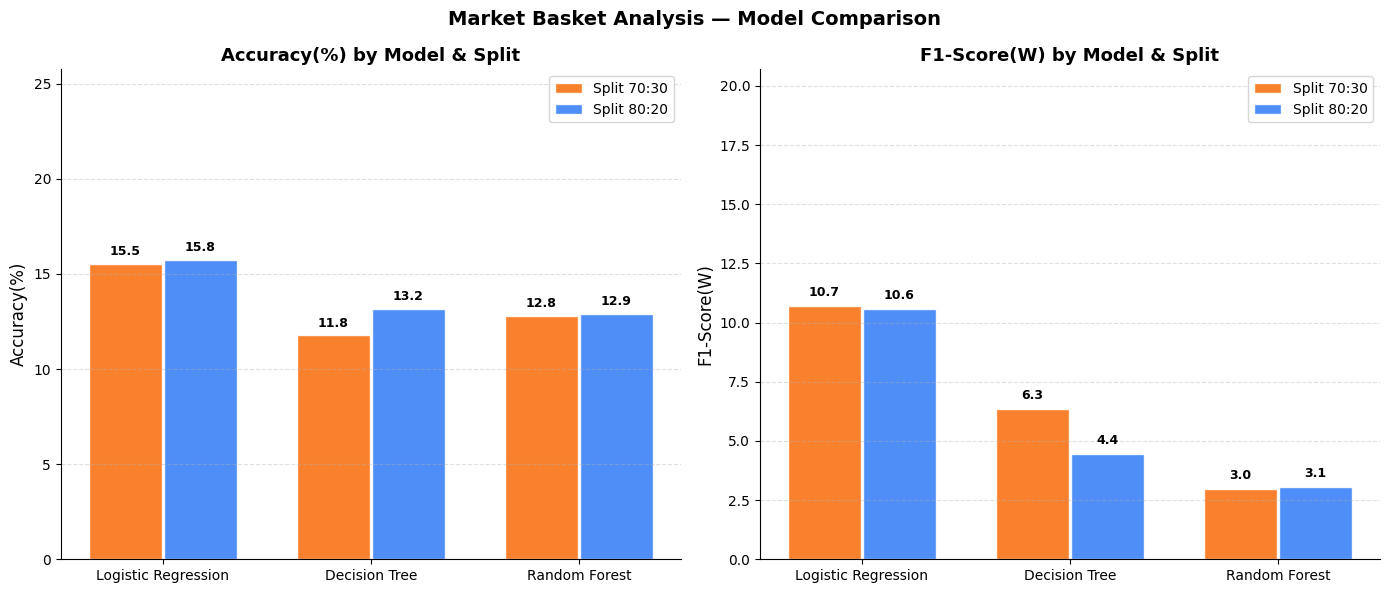


🏆 Best Model : Logistic Regression  |  Split: 80:20
   Accuracy   : 15.76
   F1 Score   : 10.58


In [ ]:
# Bar Chart — Accuracy Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {'80:20': '#3b82f6', '70:30': '#f97316'}
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

for ax, metric in zip(axes, ['Accuracy(%)', 'F1-Score(W)']):
    for split in ['70:30', '80:20']:
        grp = final_results[final_results['Split'] == split]
        x = np.arange(len(grp))
        offset = -0.18 if split == '70:30' else 0.18
        bars = ax.bar(x + offset, grp[metric], width=0.35,
                      label=f'Split {split}', color=colors[split],
                      edgecolor='white', alpha=0.9)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f'{bar.get_height():.1f}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(models, fontsize=10)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} by Model & Split', fontsize=13, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, min(100, final_results[metric].max() + 10))
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Market Basket Analysis — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

best = final_results.loc[final_results['Accuracy(%)'].idxmax()]
print(f'\n🏆 Best Model : {best["Model"]}  |  Split: {best["Split"]}')
print(f'   Accuracy   : {best["Accuracy(%)"]}')
print(f'   F1 Score   : {best["F1-Score(W)"]}')

In [ ]:
# Save results
final_results.to_csv('model_results.csv', index=False)
rules[['antecedents','consequents','support','confidence','lift']].to_csv('association_rules.csv', index=False)
print('✅ model_results.csv saved')
print('✅ association_rules.csv saved')

✅ model_results.csv saved
✅ association_rules.csv saved
